# ANN LAB 03 — Solved Notebook

This notebook completes **Lab Tasks 1–9** using a Perceptron implemented **from scratch with NumPy**.

- **Dataset 1:** Wisconsin Diagnostic Breast Cancer dataset (binary classification)
- **Dataset 2:** Iris dataset restricted to two classes for the experimental study
- **Initializations studied:** Default/Uniform, Gaussian, Xavier/Glorot, He/Kaiming, Orthogonal
- **Evaluation:** Learning curves, convergence epochs, final weights/bias, test accuracy, and repeated-run analysis


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## Lab Task 1 — Dataset Loading and Visualization

We use the **Wisconsin Diagnostic Breast Cancer** dataset.  
The target is binary:

- `0` = malignant
- `1` = benign


In [2]:
# Load the breast cancer dataset
bc = load_breast_cancer(as_frame=True)
df = bc.frame.copy()

print("Dataset shape:", df.shape)
print("\nTarget names:", bc.target_names)
print("\nFirst 5 rows:")
display(df.head())

print("\nFeatures:")
print(list(bc.feature_names))

print("\nTarget variable: target")
print("\nClass distribution:")
print(df["target"].value_counts().sort_index())

print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")


Dataset shape: (569, 31)

Target names: ['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Features:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]

Target variable: target

Class distribution:
target
0    212
1    357
Name: count, dtype: int64

Missing values per column:
No missing values.

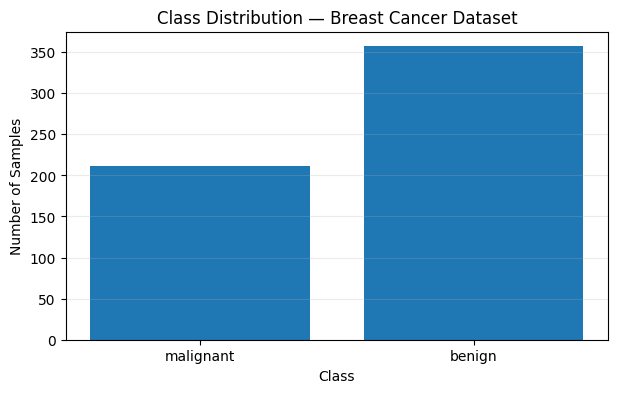

In [3]:
# Class distribution plot
class_counts = df["target"].value_counts().sort_index()
labels = [bc.target_names[i] for i in class_counts.index]

plt.figure(figsize=(7, 4))
plt.bar(labels, class_counts.values)
plt.title("Class Distribution — Breast Cancer Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.25)
plt.show()


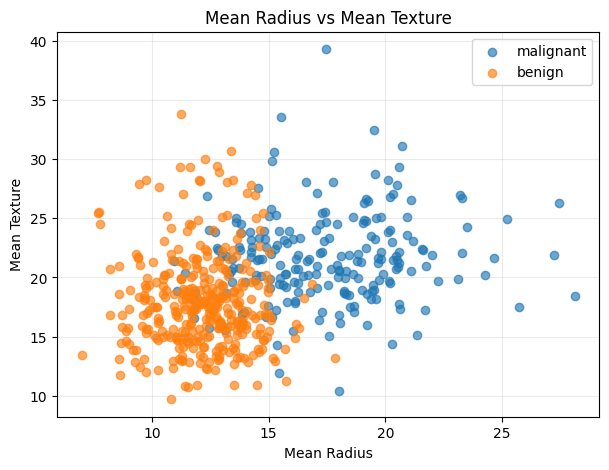

In [4]:
# Visualize two important features
plt.figure(figsize=(7, 5))
for class_value, class_name in enumerate(bc.target_names):
    subset = df[df["target"] == class_value]
    plt.scatter(
        subset["mean radius"],
        subset["mean texture"],
        label=class_name,
        alpha=0.65
    )

plt.title("Mean Radius vs Mean Texture")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [5]:
# Prepare features and target
X = df.drop(columns=["target"]).to_numpy(dtype=float)
y = df["target"].to_numpy(dtype=int)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Standardize features using training statistics only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Testing set :", X_test_scaled.shape)
print("Number of features:", X_train_scaled.shape[1])


Training set: (455, 30)
Testing set : (114, 30)
Number of features: 30


## Lab Task 2 — Basic Perceptron Implementation

The prediction rule is:

\[
\hat{y} =
\begin{cases}
1, & \text{if } w^Tx + b \ge 0 \\
0, & \text{otherwise}
\end{cases}
\]

For a training sample, the update is:

\[
w \leftarrow w + \eta (y-\hat{y})x
\]

\[
b \leftarrow b + \eta (y-\hat{y})
\]

where \(\eta\) is the learning rate.


In [6]:
class PerceptronScratch:
    def __init__(
        self,
        learning_rate=0.01,
        max_epochs=100,
        initialization="default",
        seed=42,
        gaussian_mean=0.0,
        gaussian_std=0.01,
        shuffle=False
    ):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.initialization = initialization.lower()
        self.seed = seed
        self.gaussian_mean = gaussian_mean
        self.gaussian_std = gaussian_std
        self.shuffle = shuffle

        self.weights = None
        self.bias = 0.0
        self.errors_per_epoch = []
        self.convergence_epoch = None

    def _initialize_weights(self, n_features):
        rng = np.random.default_rng(self.seed)

        if self.initialization in ("default", "random", "uniform"):
            # Small uniform random values
            return rng.uniform(-0.01, 0.01, size=n_features)

        elif self.initialization == "gaussian":
            return rng.normal(
                loc=self.gaussian_mean,
                scale=self.gaussian_std,
                size=n_features
            )

        elif self.initialization in ("xavier", "glorot"):
            fan_in = n_features
            fan_out = 1
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=n_features)

        elif self.initialization in ("he", "kaiming"):
            fan_in = n_features
            std = np.sqrt(2.0 / fan_in)
            return rng.normal(0.0, std, size=n_features)

        elif self.initialization == "orthogonal":
            # For a single perceptron, the weight matrix has one row.
            # A normalized random vector is an orthogonal 1 x n matrix.
            vector = rng.normal(size=n_features)
            norm = np.linalg.norm(vector)
            if norm == 0:
                vector[0] = 1.0
                norm = 1.0
            return vector / norm

        else:
            raise ValueError(f"Unknown initialization: {self.initialization}")

    def _step(self, z):
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        n_samples, n_features = X.shape
        self.weights = self._initialize_weights(n_features)
        self.bias = 0.0
        self.errors_per_epoch = []
        self.convergence_epoch = None

        rng = np.random.default_rng(self.seed)

        for epoch in range(1, self.max_epochs + 1):
            errors = 0

            if self.shuffle:
                indices = rng.permutation(n_samples)
            else:
                indices = np.arange(n_samples)

            for idx in indices:
                x_i = X[idx]
                target = y[idx]

                linear_output = np.dot(x_i, self.weights) + self.bias
                prediction = self._step(linear_output)

                update = self.learning_rate * (target - prediction)

                if update != 0:
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1

            self.errors_per_epoch.append(errors)

            # Perceptron has converged if it makes no errors in a full epoch
            if errors == 0:
                self.convergence_epoch = epoch
                break

        if self.convergence_epoch is None:
            self.convergence_epoch = self.max_epochs

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        linear_output = X @ self.weights + self.bias
        return (linear_output >= 0).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


In [7]:
# Train the basic perceptron
basic_model = PerceptronScratch(
    learning_rate=0.01,
    max_epochs=100,
    initialization="default",
    seed=RANDOM_STATE
)

basic_model.fit(X_train_scaled, y_train)
basic_accuracy = basic_model.score(X_test_scaled, y_test)

print(f"Test accuracy: {basic_accuracy:.4f}")
print(f"Epochs used: {len(basic_model.errors_per_epoch)}")
print(f"Convergence epoch: {basic_model.convergence_epoch}")


Test accuracy: 0.9561
Epochs used: 100
Convergence epoch: 100


## Lab Task 3 — Learning Curve and Weight Visualization


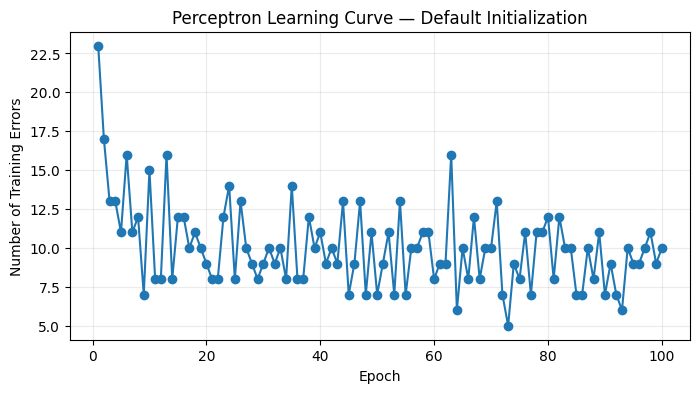

Final bias: -0.009999999999999997

Final weights:
[-0.0138  0.0104 -0.0113 -0.0391 -0.0569  0.3511 -0.1428 -0.1052  0.0313
 -0.1306 -0.1059  0.0556  0.078  -0.2038 -0.0628 -0.105   0.3158 -0.1475
  0.0485  0.1084 -0.0893 -0.1547 -0.0211 -0.1573 -0.0006  0.0556 -0.259
  0.004  -0.1264  0.0655]


In [8]:
# Learning curve for the default perceptron
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(basic_model.errors_per_epoch) + 1),
    basic_model.errors_per_epoch,
    marker="o"
)
plt.title("Perceptron Learning Curve — Default Initialization")
plt.xlabel("Epoch")
plt.ylabel("Number of Training Errors")
plt.grid(alpha=0.25)
plt.show()

print("Final bias:", basic_model.bias)
print("\nFinal weights:")
print(basic_model.weights)


### 2D Decision Boundary

Because the full breast-cancer model uses 30 features, its decision boundary cannot be directly drawn in 2D.  
For visualization only, we train a second perceptron using **mean radius** and **mean texture**.


In [9]:
# Prepare two features for decision-boundary visualization
two_features = ["mean radius", "mean texture"]
X2 = df[two_features].to_numpy(dtype=float)
y2 = y.copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y2
)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

model_2d = PerceptronScratch(
    learning_rate=0.01,
    max_epochs=100,
    initialization="default",
    seed=RANDOM_STATE
)
model_2d.fit(X2_train_s, y2_train)

print(f"2D test accuracy: {model_2d.score(X2_test_s, y2_test):.4f}")
print("2D final weights:", model_2d.weights)
print("2D final bias:", model_2d.bias)


2D test accuracy: 0.8772
2D final weights: [-0.0381 -0.0115]
2D final bias: 0.009999999999999997


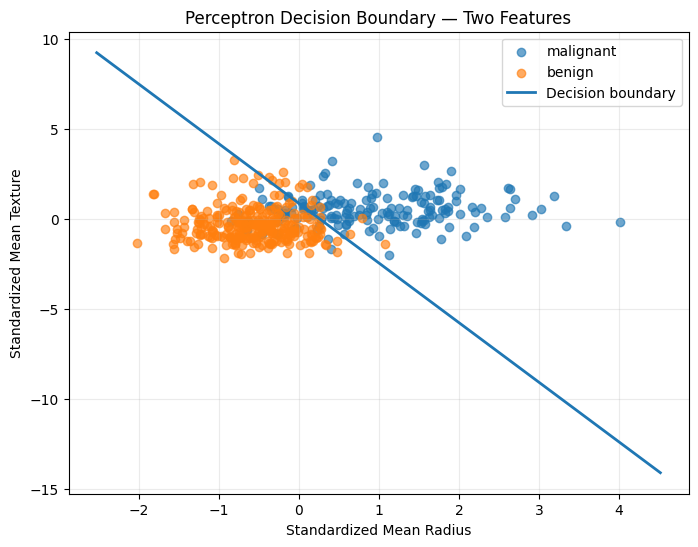

In [10]:
# Plot the 2D decision boundary in standardized feature space
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(bc.target_names):
    mask = y2_train == class_value
    plt.scatter(
        X2_train_s[mask, 0],
        X2_train_s[mask, 1],
        label=class_name,
        alpha=0.65
    )

w1, w2 = model_2d.weights
b = model_2d.bias

x_min, x_max = X2_train_s[:, 0].min() - 0.5, X2_train_s[:, 0].max() + 0.5
x_values = np.linspace(x_min, x_max, 200)

if abs(w2) > 1e-12:
    y_values = -(w1 * x_values + b) / w2
    plt.plot(x_values, y_values, linewidth=2, label="Decision boundary")
elif abs(w1) > 1e-12:
    plt.axvline(-b / w1, linewidth=2, label="Decision boundary")

plt.title("Perceptron Decision Boundary — Two Features")
plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


**Interpretation:** The line represents all points for which \(w^Tx+b=0\).  
Samples on one side are predicted as class 0 and samples on the other side are predicted as class 1.  
The two classes overlap in this 2D projection, so perfect separation is not expected.


## Lab Tasks 4–7 — Gaussian, Xavier, He, and Orthogonal Initialization

All models below use the **same training data, learning rate, maximum epochs, and training procedure**.  
Only the initial weight values are changed.


In [11]:
def train_and_summarize(
    initialization,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    seed=RANDOM_STATE,
    learning_rate=0.01,
    max_epochs=100
):
    model = PerceptronScratch(
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        initialization=initialization,
        seed=seed
    )
    model.fit(X_train, y_train)

    return {
        "model": model,
        "initialization": initialization,
        "epochs": len(model.errors_per_epoch),
        "convergence_epoch": model.convergence_epoch,
        "final_training_error": model.errors_per_epoch[-1],
        "test_accuracy": model.score(X_test, y_test),
        "bias": model.bias,
        "weights": model.weights.copy()
    }


### Lab Task 4 — Gaussian Weight Initialization

In [12]:
default_result = train_and_summarize("default")
gaussian_result = train_and_summarize("gaussian")

print("Default/Random Initialization")
print("Convergence epoch:", default_result["convergence_epoch"])
print("Final training error:", default_result["final_training_error"])
print("Test accuracy:", round(default_result["test_accuracy"], 4))
print("Final bias:", default_result["bias"])
print("Final weights:", default_result["weights"])

print("\nGaussian Initialization")
print("Convergence epoch:", gaussian_result["convergence_epoch"])
print("Final training error:", gaussian_result["final_training_error"])
print("Test accuracy:", round(gaussian_result["test_accuracy"], 4))
print("Final bias:", gaussian_result["bias"])
print("Final weights:", gaussian_result["weights"])


Default/Random Initialization
Convergence epoch: 100
Final training error: 10
Test accuracy: 0.9561
Final bias: -0.009999999999999997
Final weights: [-0.0138  0.0104 -0.0113 -0.0391 -0.0569  0.3511 -0.1428 -0.1052  0.0313
 -0.1306 -0.1059  0.0556  0.078  -0.2038 -0.0628 -0.105   0.3158 -0.1475
  0.0485  0.1084 -0.0893 -0.1547 -0.0211 -0.1573 -0.0006  0.0556 -0.259
  0.004  -0.1264  0.0655]

Gaussian Initialization
Convergence epoch: 100
Final training error: 11
Test accuracy: 0.9649
Final bias: -0.04
Final weights: [-0.0244  0.0436 -0.0101 -0.0488 -0.0516  0.3523 -0.1401 -0.0966  0.0098
 -0.1109 -0.1103  0.0319  0.0994 -0.2067 -0.033  -0.1663  0.3114 -0.1474
  0.0522  0.0581 -0.0994 -0.1831 -0.0113 -0.1697  0.0015  0.0415 -0.2638
 -0.0182 -0.1451  0.0478]


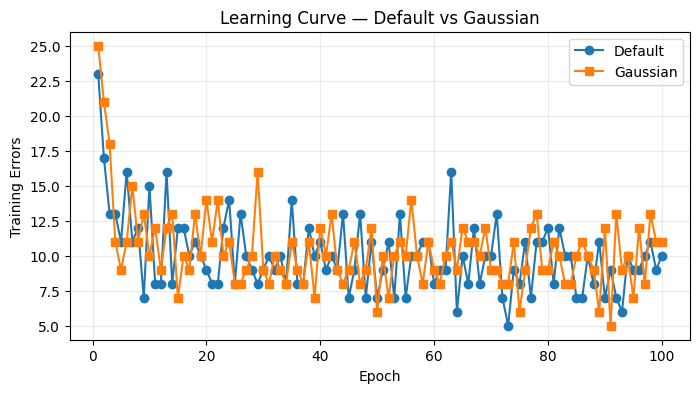

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(default_result["model"].errors_per_epoch) + 1),
    default_result["model"].errors_per_epoch,
    marker="o",
    label="Default"
)
plt.plot(
    range(1, len(gaussian_result["model"].errors_per_epoch) + 1),
    gaussian_result["model"].errors_per_epoch,
    marker="s",
    label="Gaussian"
)
plt.title("Learning Curve — Default vs Gaussian")
plt.xlabel("Epoch")
plt.ylabel("Training Errors")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Lab Task 5 — Xavier/Glorot Initialization

For Xavier normal initialization:

\[
\sigma = \sqrt{\frac{2}{fan_{in}+fan_{out}}}
\]


In [14]:
xavier_result = train_and_summarize("xavier")

print("Xavier Initialization")
print("Convergence epoch:", xavier_result["convergence_epoch"])
print("Final training error:", xavier_result["final_training_error"])
print("Test accuracy:", round(xavier_result["test_accuracy"], 4))
print("Final bias:", xavier_result["bias"])
print("Final weights:", xavier_result["weights"])


Xavier Initialization
Convergence epoch: 100
Final training error: 11
Test accuracy: 0.9561
Final bias: -0.03
Final weights: [-0.0798 -0.0091  0.0558  0.0326 -0.0556  0.3221 -0.1975 -0.0949  0.0422
 -0.1015 -0.1415  0.0263 -0.008  -0.0683 -0.0148 -0.1312  0.332  -0.1488
  0.0452  0.0728 -0.2734 -0.1546  0.1505 -0.3204 -0.0058  0.1051 -0.2766
 -0.0016 -0.1341  0.069 ]


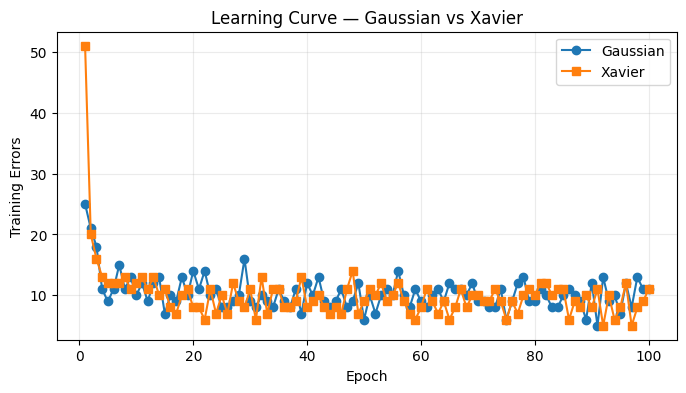

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(gaussian_result["model"].errors_per_epoch) + 1),
    gaussian_result["model"].errors_per_epoch,
    marker="o",
    label="Gaussian"
)
plt.plot(
    range(1, len(xavier_result["model"].errors_per_epoch) + 1),
    xavier_result["model"].errors_per_epoch,
    marker="s",
    label="Xavier"
)
plt.title("Learning Curve — Gaussian vs Xavier")
plt.xlabel("Epoch")
plt.ylabel("Training Errors")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Lab Task 6 — He/Kaiming Initialization

For He normal initialization:

\[
\sigma = \sqrt{\frac{2}{fan_{in}}}
\]


In [16]:
he_result = train_and_summarize("he")

print("He Initialization")
print("Convergence epoch:", he_result["convergence_epoch"])
print("Final training error:", he_result["final_training_error"])
print("Test accuracy:", round(he_result["test_accuracy"], 4))
print("Final bias:", he_result["bias"])
print("Final weights:", he_result["weights"])


He Initialization
Convergence epoch: 100
Final training error: 9
Test accuracy: 0.9649
Final bias: -0.019999999999999997
Final weights: [-0.0554 -0.0175  0.087   0.0579 -0.051   0.3424 -0.2009 -0.0789  0.04
 -0.1028 -0.1298  0.0481 -0.0095 -0.0778 -0.044  -0.1311  0.304  -0.1806
  0.0841  0.0839 -0.2445 -0.1294  0.1849 -0.3149 -0.0124  0.0685 -0.2662
 -0.0149 -0.1446  0.0433]


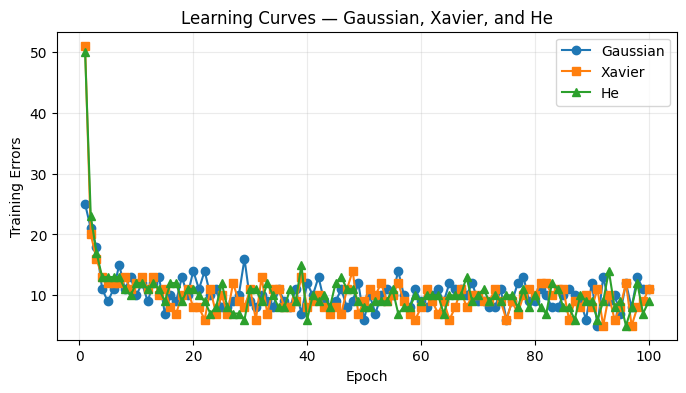

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(gaussian_result["model"].errors_per_epoch) + 1),
    gaussian_result["model"].errors_per_epoch,
    marker="o",
    label="Gaussian"
)
plt.plot(
    range(1, len(xavier_result["model"].errors_per_epoch) + 1),
    xavier_result["model"].errors_per_epoch,
    marker="s",
    label="Xavier"
)
plt.plot(
    range(1, len(he_result["model"].errors_per_epoch) + 1),
    he_result["model"].errors_per_epoch,
    marker="^",
    label="He"
)
plt.title("Learning Curves — Gaussian, Xavier, and He")
plt.xlabel("Epoch")
plt.ylabel("Training Errors")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Lab Task 7 — Orthogonal Initialization

In [18]:
orthogonal_result = train_and_summarize("orthogonal")

print("Orthogonal Initialization")
print("Convergence epoch:", orthogonal_result["convergence_epoch"])
print("Final training error:", orthogonal_result["final_training_error"])
print("Test accuracy:", round(orthogonal_result["test_accuracy"], 4))
print("Final bias:", orthogonal_result["bias"])
print("Final weights:", orthogonal_result["weights"])


Orthogonal Initialization
Convergence epoch: 100
Final training error: 8
Test accuracy: 0.9561
Final bias: -0.03
Final weights: [-0.0664 -0.0134  0.0652  0.0289 -0.0462  0.3513 -0.2085 -0.1017  0.0672
 -0.0873 -0.1214  0.0372  0.0056 -0.0751 -0.0209 -0.1441  0.3421 -0.1862
  0.067   0.0816 -0.2377 -0.1463  0.1622 -0.3031 -0.021   0.0639 -0.2624
 -0.0159 -0.1434  0.0441]


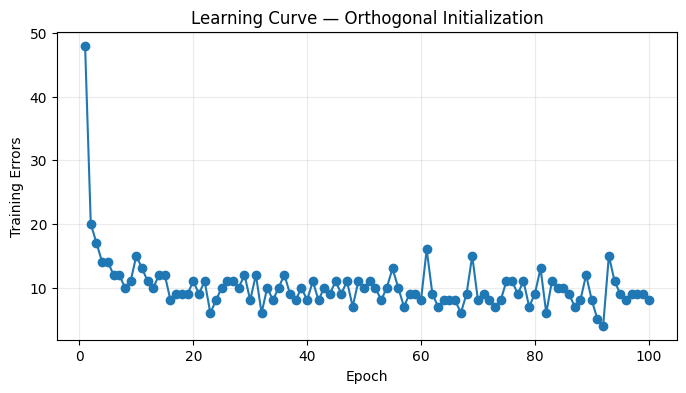

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(orthogonal_result["model"].errors_per_epoch) + 1),
    orthogonal_result["model"].errors_per_epoch,
    marker="o"
)
plt.title("Learning Curve — Orthogonal Initialization")
plt.xlabel("Epoch")
plt.ylabel("Training Errors")
plt.grid(alpha=0.25)
plt.show()


## Lab Task 8 — Comparative Analysis of Weight Initialization Techniques


In [20]:
results = {
    "Gaussian": gaussian_result,
    "Xavier": xavier_result,
    "He": he_result,
    "Orthogonal": orthogonal_result
}

comparison_rows = []
for name, result in results.items():
    comparison_rows.append({
        "Initialization": name,
        "Epochs Used": result["epochs"],
        "Convergence Epoch": result["convergence_epoch"],
        "Final Training Error": result["final_training_error"],
        "Test Accuracy": result["test_accuracy"],
        "Final Bias": result["bias"],
        "Final Weights": np.array2string(
            result["weights"],
            precision=4,
            threshold=8,
            edgeitems=3
        )
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,Initialization,Epochs Used,Convergence Epoch,Final Training Error,Test Accuracy,Final Bias,Final Weights
0,Gaussian,100,100,11,0.964912,-0.04,[-0.0244 0.0436 -0.0101 ... -0.0182 -0.1451 ...
1,Xavier,100,100,11,0.956140,-0.03,[-0.0798 -0.0091 0.0558 ... -0.0016 -0.1341 ...
2,He,100,100,9,0.964912,-0.02,[-0.0554 -0.0175 0.087 ... -0.0149 -0.1446 ...
3,Orthogonal,100,100,8,0.956140,-0.03,[-0.0664 -0.0134 0.0652 ... -0.0159 -0.1434 ...


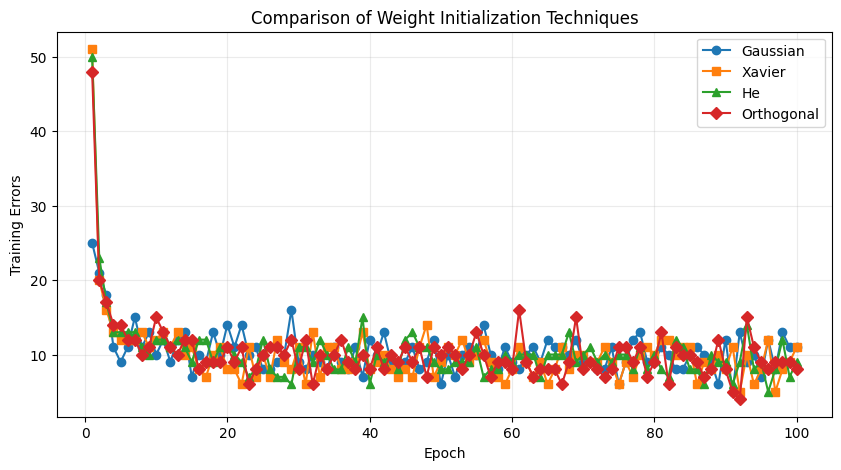

In [21]:
# Plot all four learning curves
plt.figure(figsize=(10, 5))

markers = ["o", "s", "^", "D"]
for marker, (name, result) in zip(markers, results.items()):
    errors = result["model"].errors_per_epoch
    plt.plot(
        range(1, len(errors) + 1),
        errors,
        marker=marker,
        label=name
    )

plt.title("Comparison of Weight Initialization Techniques")
plt.xlabel("Epoch")
plt.ylabel("Training Errors")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Short Analysis

Different initialization techniques give the perceptron different starting positions in weight space.  
Therefore, even when the dataset and hyperparameters are unchanged:

1. The early predictions can be different.
2. Different samples may trigger updates.
3. The weight-update path can change.
4. The final weights may differ even when test accuracy is similar.
5. If the data are not perfectly linearly separable, the model may never reach zero errors before the maximum epoch limit.

Xavier and He initializations are especially important in deep neural networks because they are designed to control signal variance across layers. In a single-layer perceptron, their advantage is usually less dramatic, but they still change the starting scale of the weights.


## Lab Task 9 — Experimental Study and Interpretation

A **different binary dataset** is used here: the Iris dataset restricted to:

- class 0 = setosa
- class 1 = versicolor

Multiple random seeds are used for each initialization technique.


In [22]:
# Load a second dataset: Iris, restricted to two classes
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()

# Keep only setosa (0) and versicolor (1)
iris_binary = iris_df[iris_df["target"].isin([0, 1])].copy()

X_iris = iris_binary.drop(columns=["target"]).to_numpy(dtype=float)
y_iris = iris_binary["target"].to_numpy(dtype=int)

print("Binary Iris dataset shape:", iris_binary.shape)
print("Features:", list(iris.feature_names))
print("\nClass distribution:")
print(iris_binary["target"].value_counts().sort_index())


Binary Iris dataset shape: (100, 5)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class distribution:
target
0    50
1    50
Name: count, dtype: int64


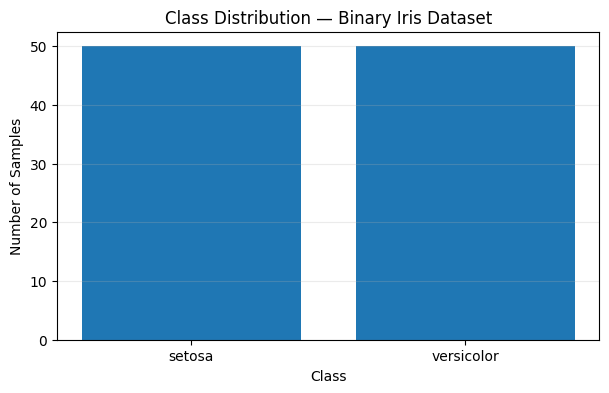

In [23]:
plt.figure(figsize=(7, 4))
iris_counts = iris_binary["target"].value_counts().sort_index()
iris_labels = [iris.target_names[i] for i in iris_counts.index]

plt.bar(iris_labels, iris_counts.values)
plt.title("Class Distribution — Binary Iris Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.25)
plt.show()


In [24]:
# Fixed split, then repeated initialization seeds
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_iris
)

iris_scaler = StandardScaler()
Xi_train_s = iris_scaler.fit_transform(Xi_train)
Xi_test_s = iris_scaler.transform(Xi_test)

initializations = ["gaussian", "xavier", "he", "orthogonal"]
seeds = [0, 1, 2, 3, 4, 5, 10, 20, 42, 99]

run_records = []

for init in initializations:
    for seed in seeds:
        model = PerceptronScratch(
            learning_rate=0.01,
            max_epochs=100,
            initialization=init,
            seed=seed
        )
        model.fit(Xi_train_s, yi_train)

        run_records.append({
            "Initialization": init.title(),
            "Seed": seed,
            "Convergence Epoch": model.convergence_epoch,
            "Final Training Error": model.errors_per_epoch[-1],
            "Test Accuracy": model.score(Xi_test_s, yi_test)
        })

runs_df = pd.DataFrame(run_records)
display(runs_df.head(12))


,Initialization,Seed,Convergence Epoch,Final Training Error,Test Accuracy
0,Gaussian,0,1,0,1.0
1,Gaussian,1,2,0,1.0
2,Gaussian,2,2,0,1.0
3,Gaussian,3,2,0,1.0
4,Gaussian,4,1,0,1.0
5,Gaussian,5,2,0,1.0
6,Gaussian,10,2,0,1.0
7,Gaussian,20,2,0,1.0
8,Gaussian,42,1,0,1.0
9,Gaussian,99,1,0,1.0


In [25]:
summary_df = (
    runs_df
    .groupby("Initialization", as_index=False)
    .agg(
        Average_Convergence_Epoch=("Convergence Epoch", "mean"),
        Std_Convergence_Epoch=("Convergence Epoch", "std"),
        Average_Test_Accuracy=("Test Accuracy", "mean"),
        Std_Test_Accuracy=("Test Accuracy", "std"),
        Average_Final_Training_Error=("Final Training Error", "mean")
    )
    .sort_values("Initialization")
)

display(summary_df)


,Initialization,Average_Convergence_Epoch,Std_Convergence_Epoch,Average_Test_Accuracy,Std_Test_Accuracy,Average_Final_Training_Error
0,Gaussian,1.6,0.516398,1.000,0.000000,0.0
1,He,7.1,6.279597,0.995,0.015811,0.0
2,Orthogonal,5.9,5.526703,1.000,0.000000,0.0
3,Xavier,6.4,5.420127,1.000,0.000000,0.0


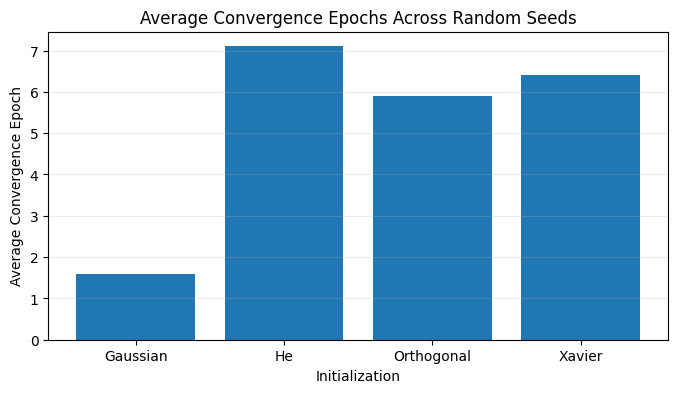

In [26]:
# Average convergence epochs
plt.figure(figsize=(8, 4))
plt.bar(
    summary_df["Initialization"],
    summary_df["Average_Convergence_Epoch"]
)
plt.title("Average Convergence Epochs Across Random Seeds")
plt.xlabel("Initialization")
plt.ylabel("Average Convergence Epoch")
plt.grid(axis="y", alpha=0.25)
plt.show()


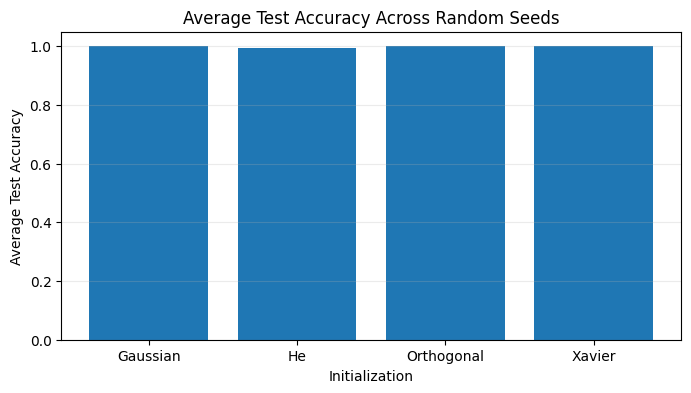

In [27]:
# Average test accuracy
plt.figure(figsize=(8, 4))
plt.bar(
    summary_df["Initialization"],
    summary_df["Average_Test_Accuracy"]
)
plt.ylim(0, 1.05)
plt.title("Average Test Accuracy Across Random Seeds")
plt.xlabel("Initialization")
plt.ylabel("Average Test Accuracy")
plt.grid(axis="y", alpha=0.25)
plt.show()


In [28]:
print("EXPERIMENTAL INTERPRETATION")
print("-" * 70)

for _, row in summary_df.iterrows():
    print(
        f"{row['Initialization']}: "
        f"avg convergence epoch = {row['Average_Convergence_Epoch']:.2f}, "
        f"avg test accuracy = {row['Average_Test_Accuracy']:.4f}"
    )

print("\nDiscussion:")
print(
    "1. Weight initialization changes the perceptron's starting decision boundary, "
    "so the number of updates and convergence speed can change."
)
print(
    "2. Dataset characteristics matter. A linearly separable dataset can reach zero "
    "training errors, while overlapping/non-separable data may continue making errors."
)
print(
    "3. Randomness changes the initial weights. With shuffling enabled it could also "
    "change the sample order; here shuffling is disabled so the initialization itself "
    "is isolated more clearly."
)
print(
    "4. Different initializations can end with different weight vectors while producing "
    "similar classifications and accuracy."
)


EXPERIMENTAL INTERPRETATION
----------------------------------------------------------------------
Gaussian: avg convergence epoch = 1.60, avg test accuracy = 1.0000
He: avg convergence epoch = 7.10, avg test accuracy = 0.9950
Orthogonal: avg convergence epoch = 5.90, avg test accuracy = 1.0000
Xavier: avg convergence epoch = 6.40, avg test accuracy = 1.0000

Discussion:
1. Weight initialization changes the perceptron's starting decision boundary, so the number of updates and convergence speed can change.
2. Dataset characteristics matter. A linearly separable dataset can reach zero training errors, while overlapping/non-separable data may continue making errors.
3. Randomness changes the initial weights. With shuffling enabled it could also change the sample order; here shuffling is disabled so the initialization itself is isolated more clearly.
4. Different initializations can end with different weight vectors while producing similar classifications and accuracy.


## Final Conclusion

This lab demonstrated a perceptron implemented from scratch and systematically studied how weight initialization affects training. Gaussian, Xavier, He, and Orthogonal initializations can produce different learning curves, convergence epochs, and final parameter values because each method starts the model at a different point in parameter space. The experiments also show that **dataset separability and randomness** strongly influence perceptron behavior.
